In [3]:
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd # para el manejo de DataFrames
import numpy as np # para el manejo de arrays y operaciones matemáticas

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt # para crear gráficos
import seaborn as sns

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames


import warnings
warnings.filterwarnings("ignore") # para evitar los mensajes de advertencia

In [4]:
#Abrimos el csv unido y limpio que hemos guardado anteriormente
df_final=pd.read_csv("files/df_final.csv")


In [5]:
df_final.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.38,258961.51,100018.00,326699.00,550598.00,772152.00,999986.00
salary,403760.0,77422.51,30194.42,9081.00,63901.00,71675.47,82940.00,407228.00
clv,403760.0,7990.86,6863.32,1898.01,3981.78,5776.34,8937.12,83325.38
enrollment_year,403760.0,2015.25,1.98,2012.00,2014.00,2015.00,2017.00,2018.00
enrollment_month,403760.0,6.67,3.40,1.00,4.00,7.00,10.00,12.00
cancellation_year,49650.0,2016.50,1.38,2013.00,2016.00,2017.00,2018.00,2018.00
cancellation_month,49650.0,6.96,3.45,1.00,4.00,7.00,10.00,12.00
year,403760.0,2017.50,0.50,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.50,3.45,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.13,5.23,0.00,0.00,1.00,8.00,21.00


### Fase 2: Análisis estadístico:
**-. 2.1 Análisis de variables numéricas:(Estadísticas descriptivas,outliers y análisis de correlación)**
Analizamos las variables más relvantes:

- SALARIO: Vemos que el salario minimo y maximo es muy diferente (9k vs 407k ).Por otro lado también vemos que está muy alejado de la media que son 77k.Además la mediana es 71k.También vemos que el 75% de los clientes cobran menos de 82k.Posible outlier

- CLV: El valor mínimo y el valor maximo están muy alejados:min 1,8k y max 83k.Aquí vemos que hay un cliente estrella pero no se acerca a lo habitual.También lo vemos en que el 75 % de los clientes gasta menos de 9k.La media está en 8k y la mediana en 5.7k.La media está empujada a la alza por los posibles outliers.

- TOTAL FLIGHTS:Vemos que 75% de los clients realiza menos de 10 viajes, sin embargo el maximos es 32 viajes.Posible outlier

- DISTANCE:Vemos el minimo el 0 porque no hay vuelos registrados.Pero si vemos que la distancia media es de 1200km y la maxima es de 6293km.También vemos que el 50% de los vuelos son de menos de 525km.(La mediana es 525km)Posible outlier

- POINTS REDEEMED:Vemos que la media de puntos canjeados es de 30 puntos, sin embargo vemos que el maximo es 876 puntos.Una diferencia bastante grande.Posible outlier


<Axes: xlabel='salary'>

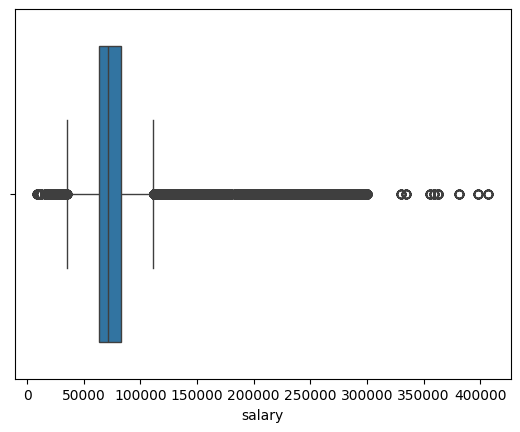

In [ ]:

#vamos a ver si hay outliers en las variables que hemos seleccionado como era muy probable que tuvieran outliers
sns.boxplot(data=df_final, x="salary")

En este boxplot vemos perfectamente la presencia de outliers o valores atípicos:
-El 50% de nuestros datos se encuentra en el llamado rango interciartílico(IQR).Es decir. el 50% de los clientes tiene un salario de 80k€ y vemos que hay clientes que cobra más de 400k€
-El 25% de los salarios de los clientes es inferior al Q1, es decir, el 25% de los clientes cobra menos de 64k€ aprox
-El 75€ de los clientes tiene un salario inferior a 83k€
-La mediana está 72k€

Todo lo que sobresale de los bigotes , son outliers

In [29]:
df_final[["salary"]].describe().T

,count,mean,std,min,25%,50%,75%,max
salary,403760.0,77422.505227,30194.419606,9081.0,63901.0,71675.466852,82940.0,407228.0


<Axes: xlabel='clv'>

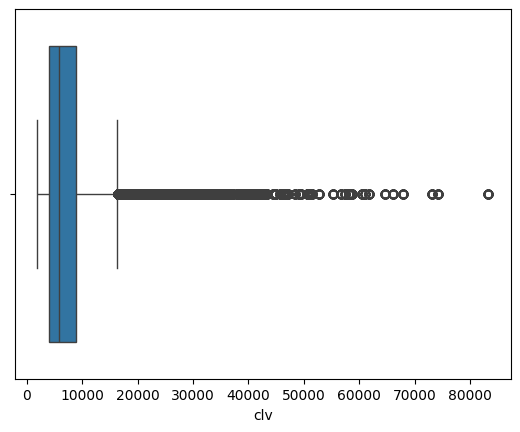

In [24]:
sns.boxplot(data=df_final, x="clv")

<Axes: xlabel='total_flights'>

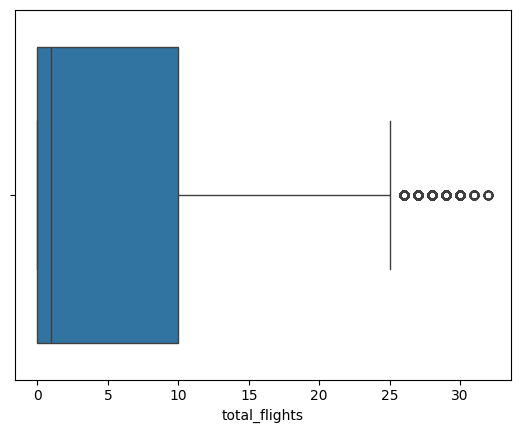

In [25]:
sns.boxplot(data=df_final, x="total_flights")

<Axes: xlabel='distance'>

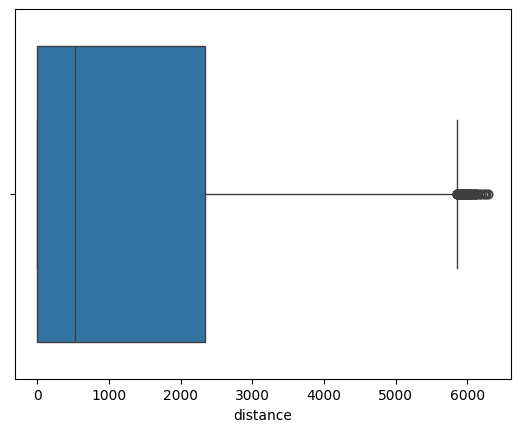

In [26]:
sns.boxplot(data=df_final, x="distance")

<Axes: xlabel='points_redeemed'>

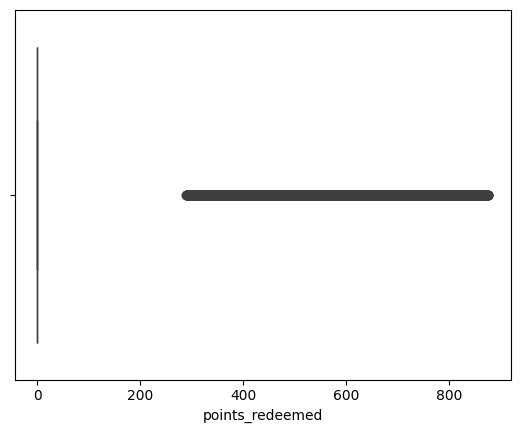

In [27]:
sns.boxplot(data=df_final, x="points_redeemed")

In [ ]:
#En este gráfico que la mayoría de los clientes no han canjeado puntos,pero por otro lado, vemos que p hay algunos clientes que han canjeado muchos puntos 876 puntos

In [30]:
df_final[["points_redeemed"]].describe().T

,count,mean,std,min,25%,50%,75%,max
points_redeemed,403760.0,30.838587,125.758002,0.0,0.0,0.0,0.0,876.0


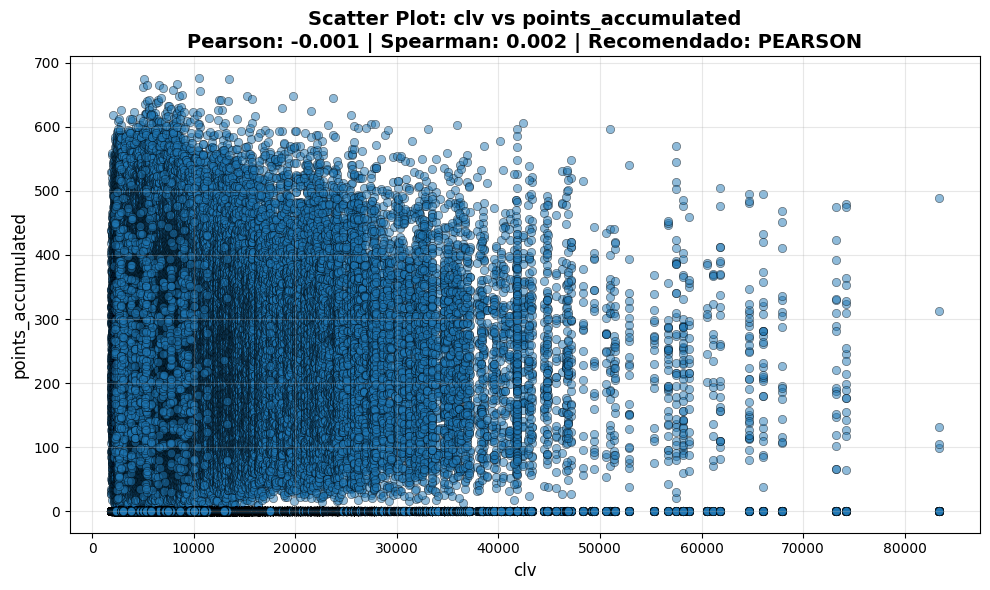

In [11]:
#Análisis de correlación:
#importamos la función de correlación de la carpeta src
from src.soporte_correlacion import comparar_correlaciones
comparar_correlaciones(df_final, 'clv', 'points_accumulated');


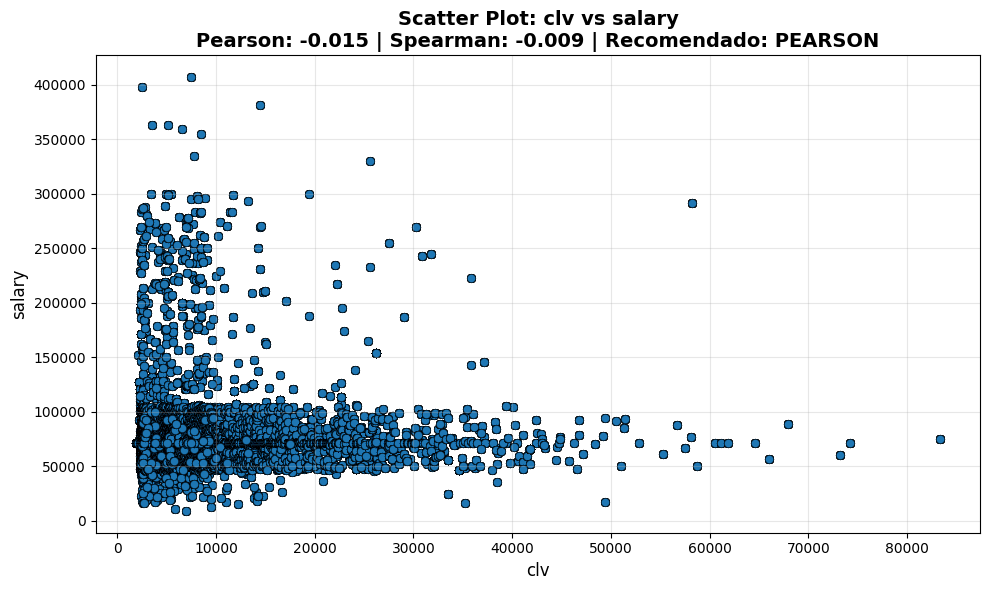

In [12]:
comparar_correlaciones(df_final, 'clv', 'salary');



Análisis de correlación (variables numéricas):

-   points_accumulated y distance (0.99):A mayor distancia recorrida, más puntos acumula el cliente.CORRELACIÓN POSITIVA MUY FUERTE

-   total_flights y flights_booked (0.96): Cuantas más reservas, más vuelos.CORRELACIÓN POSITIVA MUY  FUERTE

-   points_redeemed y dollar_cost_points_redeemed (1.00): CORRELACIÓN POSITIVA PERFECTA.Se podría borrar una de las variables ya que nos aportan la misma información, una en dólares y la otra en puntos

-   flights_booked con distance (0.77):CORRELACIÓN POSITIVA FUERTE Quienes reservan más vuelos tienden a viajar distancias más largas

-   flights_booked con points_accumulated (0.76):CORRELACIÓN POSITIVA FUERTE.Cuantos más vuelos reservados,más puntos.




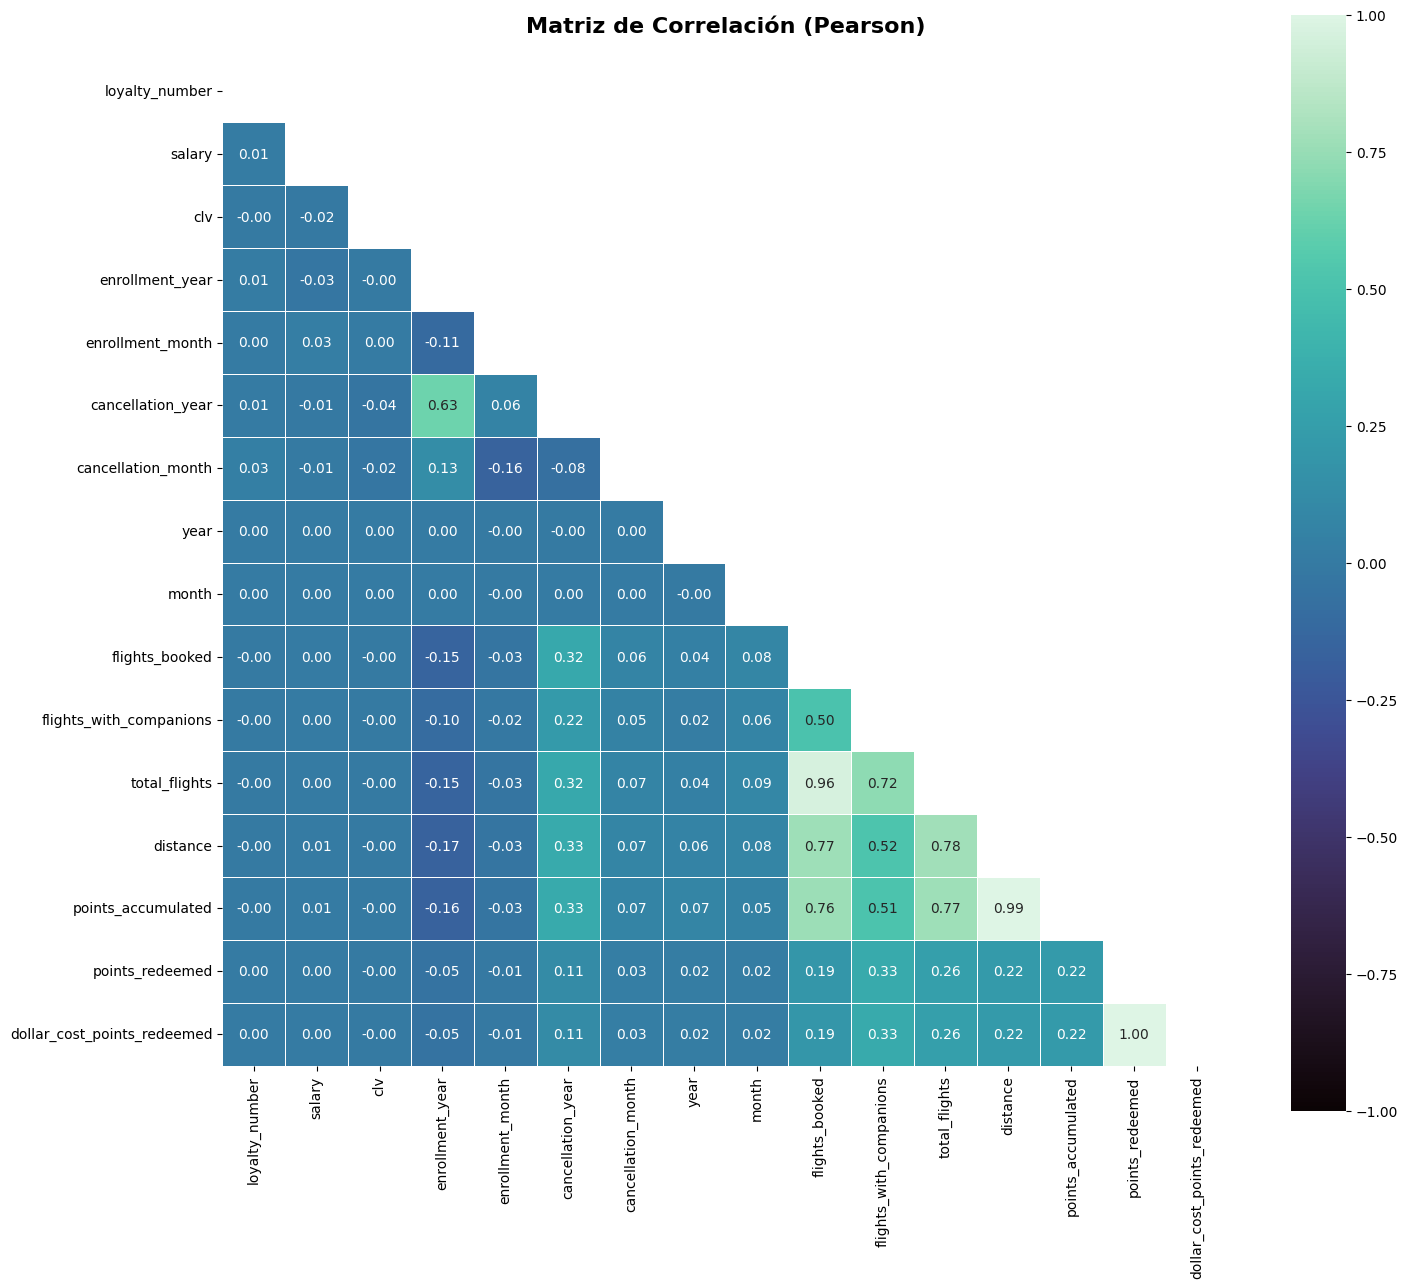

,loyalty_number,salary,clv,enrollment_year,enrollment_month,cancellation_year,cancellation_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
loyalty_number,1.000000,0.011677,-0.000625,0.008209,0.004877,0.007354,0.033378,0.000391,0.000199,-0.002280,-0.003069,-0.002805,-0.001779,-0.001792,0.000647,0.000641
salary,0.011677,1.000000,-0.015427,-0.030547,0.026270,-0.008011,-0.006540,0.000088,0.000041,0.004639,0.001600,0.004227,0.006661,0.006573,0.001965,0.001959
clv,-0.000625,-0.015427,1.000000,-0.002212,0.002663,-0.036073,-0.024523,0.000187,0.000051,-0.002847,-0.002510,-0.003081,-0.004132,-0.000942,-0.000265,-0.000238
enrollment_year,0.008209,-0.030547,-0.002212,1.000000,-0.114121,0.634086,0.128991,0.000500,0.000211,-0.153305,-0.096835,-0.153712,-0.165141,-0.164520,-0.047759,-0.047808
enrollment_month,0.004877,0.026270,0.002663,-0.114121,1.000000,0.056086,-0.163925,-0.000243,-0.000120,-0.031550,-0.019639,-0.031542,-0.034449,-0.033923,-0.008680,-0.008683
cancellation_year,0.007354,-0.008011,-0.036073,0.634086,0.056086,1.000000,-0.075802,-0.000044,0.000032,0.316053,0.220471,0.316461,0.330539,0.332410,0.112523,0.112596
cancellation_month,0.033378,-0.006540,-0.024523,0.128991,-0.163925,-0.075802,1.000000,0.000431,0.000099,0.064853,0.049511,0.066162,0.070337,0.069457,0.026184,0.026154
year,0.000391,0.000088,0.000187,0.000500,-0.000243,-0.000044,0.000431,1.000000,-0.000025,0.044121,0.021327,0.042153,0.055767,0.074910,0.017503,0.017495
month,0.000199,0.000041,0.000051,0.000211,-0.000120,0.000032,0.000099,-0.000025,1.000000,0.082137,0.064486,0.086373,0.076321,0.054066,0.019361,0.019267
flights_booked,-0.002280,0.004639,-0.002847,-0.153305,-0.031550,0.316053,0.064853,0.044121,0.082137,1.000000,0.501698,0.961233,0.766748,0.759547,0.187638,0.187647


In [19]:
from src.soporte_correlacion import matriz_correlacion_visual
matriz_correlacion_visual(df_final,metodo='pearson', figsize=(15, 15), cmap='mako', 
                              annot=True, fmt='.2f', solo_triangulo=True)

## Hipótesis:

Una de las variables más importantes para la aerolínea es el CLV(ya que es el dinero total que genera el cliente a la aerolínea a lo largo de su relación con ella), por lo que vamos a analizar qué variables tienen una mayor correlación con el CLV para poder sacar conclusiones y tomar decisiones.

#¿Los que cobran más tienen un clv más alto?Cuanto más cobran, más vuelan:Salary vs CLV .NO SE CUMPLE ❌
#¿Acumulan más puntos los que tienen un clv más alto?Points_accumulated vs CLV.NO SE CUMPLE ❌

Análisis de correlación (variables numéricas):

-   points_accumulated y distance (0.99):A mayor distancia recorrida, más puntos acumula el cliente.CORRELACIÓN POSITIVA MUY FUERTE

-   total_flights y flights_booked (0.96): Cuantas más reservas, más vuelos.CORRELACIÓN POSITIVA MUY  FUERTE

-   points_redeemed y dollar_cost_points_redeemed (1.00): CORRELACIÓN POSITIVA PERFECTA.Se podría borrar una de las variables ya que nos aportan la misma información, una en dólares y la otra en puntos

-   flights_booked con distance (0.77):CORRELACIÓN POSITIVA FUERTE Quienes reservan más vuelos tienden a viajar distancias más largas

-   flights_booked con points_accumulated (0.76):CORRELACIÓN POSITIVA FUERTE.Cuantos más vuelos reservados,más puntos.

-   salary y clv:CORRELACIÓN CASI NULA.Si nos fijamos, los que más dinero dan a la aerolínea no son los que tienen los sueldos más altos.No influye en absoluto.

**-. 2.2 Análisis de variables categóricas: (Distribución de frecuencias de las variables categóricas relevantes.)**



In [20]:
df_final.describe(include='object').T

,count,unique,top,freq
province,403760,11,Ontario,130258
city,403760,29,Toronto,80775
postal_code,403760,55,V6E 3D9,21944
gender,403760,2,Female,202757
education,403760,5,Bachelor,252567
marital_status,403760,3,Married,234845
loyalty_card,403760,3,Star,183745
enrollment_type,403760,2,Standard,380419


Con la ayuda del describe anterior, podemos ver que :
- Ontario es la provincia de la cual son la mayoría de clientes
- Toronto es la ciudad de la cual hay más clientes 
- La mayor parte de los clientes son mujeres
- La mayor parte de los clientes tiene estudios superiores(Bachellor)
- La mayor parte de los clientes están casados
- La loyalty card que más se repite es la targeta Start
- El enrrollement type que más hay es el tipo de inscripción standar.Con una frecuncia muy alta, de 403.760, 380.419  tiene la inscripción Standar